# Figure 4 — Step-by-step Room Construction Chain

Simulates the app's sequential selection process:
- **Step 1**: a random item is picked (no prior context)
- **Steps 2+**: the top-1 compatible recommendation given all previously selected items

The chain shows how each new item is conditioned on everything chosen before it.
Saved to `data/thesis_figures/comparison/fig4_chain__*.png` at 300 DPI.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

BASE_DIR = next(
    p for p in [Path().cwd()] + list(Path().cwd().parents)
    if (p / "src" / "retrieval" / "retrieval_logic.py").exists()
)
sys.path.insert(0, str(BASE_DIR / "src" / "retrieval"))
from retrieval_logic import FurnitureRetriever, CATEGORY_CHAINS

OUT_DIR = BASE_DIR / "data" / "thesis_figures" / "comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family":       "DejaVu Serif",
    "font.size":         9,
    "axes.titlesize":    8,
    "axes.titleweight":  "bold",
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})

STEP_LABELS = {
    "bed": "Bed", "sofa": "Sofa",
    "small_storage": "Storage", "large_storage": "Storage",
    "table": "Table", "chair_stool": "Chair / Stool", "curtain": "Curtain",
}
ROOM_LABELS = {"bedrooms": "Bedrooms", "living_rooms": "Living Rooms"}

# Step 1 = blue-grey (random), steps 2+ = green (model pick)
COLOR_RANDOM = "#546E7A"
COLOR_MODEL  = "#2E7D32"

def cat_label(cat): return STEP_LABELS.get(cat, cat)
def open_img(path): return Image.open(path).convert("RGB")

print(f"BASE_DIR : {BASE_DIR}")
print(f"Output   : {OUT_DIR}")

BASE_DIR : d:\Programing\thesis_v2_v3
Output   : d:\Programing\thesis_v2_v3\data\thesis_figures\comparison


In [2]:
def build_chain(retriever, chain_cats, seed=0):
    """
    Auto-build a room chain: step 1 is random, each subsequent step is the
    top-1 recommendation given all previously selected items.
    Returns a list of item dicts in chain order.
    """
    rng      = np.random.default_rng(seed)
    selected = []
    for i, cat in enumerate(chain_cats):
        if i == 0:
            item = retriever.get_random(cat, n=1)[0]
        else:
            item = retriever.get_compatible(selected=selected, target_category=cat, top_k=1)[0]
        selected.append(item)
    return selected


def make_chain_figure(room: str, seed: int = 0) -> plt.Figure:
    """
    Figure 4: horizontal film-strip showing the full room construction chain.

    Blue-grey border = step 1 (random starting item).
    Green border     = model recommendation conditioned on all prior picks.
    """
    retriever  = FurnitureRetriever(room=room, embed_weight=0.8, hist_weight=0.2)
    chain_cats = CATEGORY_CHAINS[room]
    selected   = build_chain(retriever, chain_cats, seed=seed)

    n        = len(chain_cats)
    room_lbl = ROOM_LABELS[room]

    # GridSpec: alternating [image col] [arrow col] [image col] ...
    CELL  = 1.75   # image cell size (inches)
    ARROW = 0.30   # arrow gap width (inches)

    widths = []
    for i in range(n):
        widths.append(CELL)
        if i < n - 1:
            widths.append(ARROW)

    fig = plt.figure(figsize=(sum(widths), CELL + 0.85))
    gs  = gridspec.GridSpec(
        2, len(widths),
        figure=fig,
        width_ratios=widths,
        height_ratios=[CELL, 0.60],
        hspace=0.06, wspace=0.0,
        top=0.86, bottom=0.02, left=0.01, right=0.99,
    )
    fig.suptitle(
        f"Step-by-step Room Construction \u2014 {room_lbl}  (seed {seed})",
        fontsize=10, fontweight="bold", y=0.97,
    )

    for i, (item, cat) in enumerate(zip(selected, chain_cats)):
        col   = i * 2
        color = COLOR_RANDOM if i == 0 else COLOR_MODEL

        # Image
        ax_img = fig.add_subplot(gs[0, col])
        ax_img.imshow(open_img(item["image_path"]))
        ax_img.axis("off")
        for sp in ax_img.spines.values():
            sp.set_visible(True)
            sp.set_linewidth(1.5)
            sp.set_edgecolor(color)
        ax_img.set_title(f"Step {i + 1}", fontsize=7.5, color=color,
                         fontweight="bold", pad=2)

        # Label below image
        ax_lbl = fig.add_subplot(gs[1, col])
        ax_lbl.axis("off")
        score = item.get("score", 0.0)
        ax_lbl.text(0.5, 0.75, cat_label(cat),
                    ha="center", va="center", fontsize=7.5,
                    fontweight="bold", color="#212121",
                    transform=ax_lbl.transAxes)
        ax_lbl.text(0.5, 0.25,
                    "random start" if score == 0.0 else f"score: {score:.3f}",
                    ha="center", va="center", fontsize=7,
                    color="#757575", transform=ax_lbl.transAxes)

        # Arrow
        if i < n - 1:
            ax_arr = fig.add_subplot(gs[0, col + 1])
            ax_arr.annotate(
                "", xy=(0.85, 0.5), xytext=(0.15, 0.5),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="#BDBDBD",
                                lw=1.5, mutation_scale=14),
            )
            ax_arr.set_xlim(0, 1)
            ax_arr.set_ylim(0, 1)
            ax_arr.axis("off")
            ax_arr.patch.set_facecolor("white")

            ax_gap = fig.add_subplot(gs[1, col + 1])
            ax_gap.axis("off")

    # Legend note
    fig.text(
        0.01, 0.01,
        "\u25a0 Blue-grey = random starting item     \u25a0 Green = model recommendation",
        ha="left", va="bottom", fontsize=7, color="#616161",
    )
    return fig


print("Figure 4 builder ready.")

Figure 4 builder ready.



Bedrooms, seed=0
Loading histogram cache...
FurnitureRetriever ready — 2662 items, 6 categories
  bed            : 553 items
  chair_stool    : 357 items
  curtain        : 431 items
  large_storage  : 368 items
  small_storage  : 636 items
  table          : 317 items


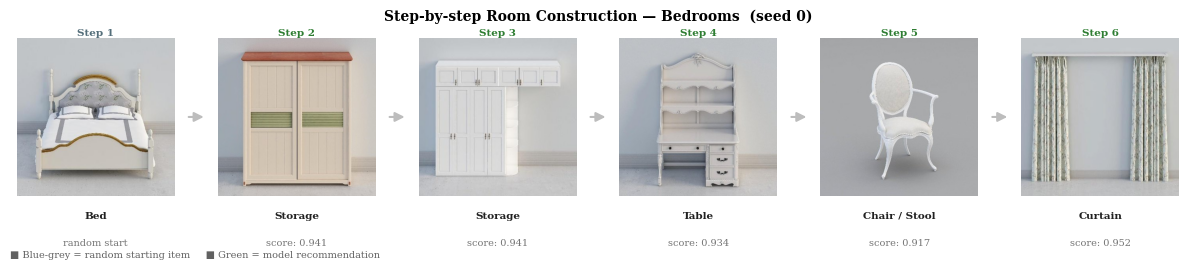

  Saved: fig4_chain__bedrooms__seed0.png

Bedrooms, seed=42
Loading histogram cache...
FurnitureRetriever ready — 2662 items, 6 categories
  bed            : 553 items
  chair_stool    : 357 items
  curtain        : 431 items
  large_storage  : 368 items
  small_storage  : 636 items
  table          : 317 items


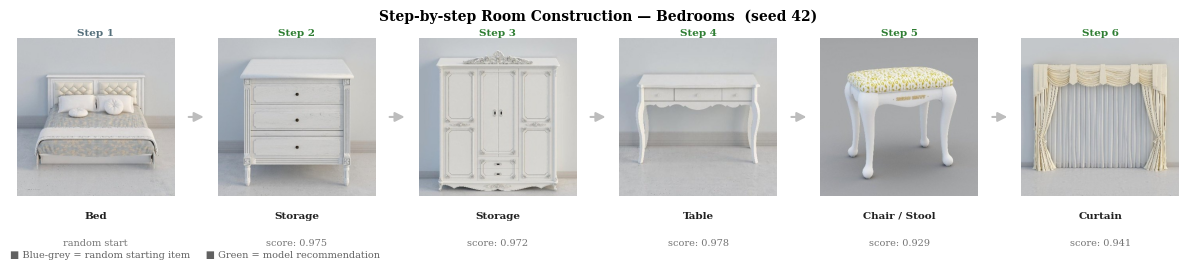

  Saved: fig4_chain__bedrooms__seed42.png

Living Rooms, seed=0
Loading histogram cache...
FurnitureRetriever ready — 2509 items, 6 categories
  chair_stool    : 220 items
  curtain        : 222 items
  large_storage  : 294 items
  small_storage  : 324 items
  sofa           : 822 items
  table          : 627 items


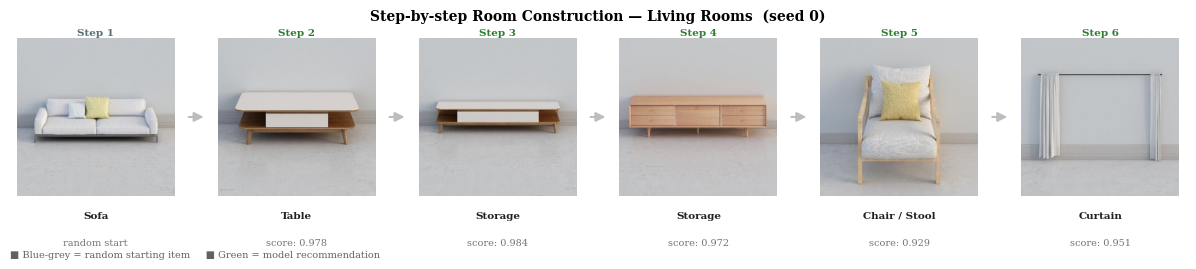

  Saved: fig4_chain__living_rooms__seed0.png

Living Rooms, seed=42
Loading histogram cache...
FurnitureRetriever ready — 2509 items, 6 categories
  chair_stool    : 220 items
  curtain        : 222 items
  large_storage  : 294 items
  small_storage  : 324 items
  sofa           : 822 items
  table          : 627 items


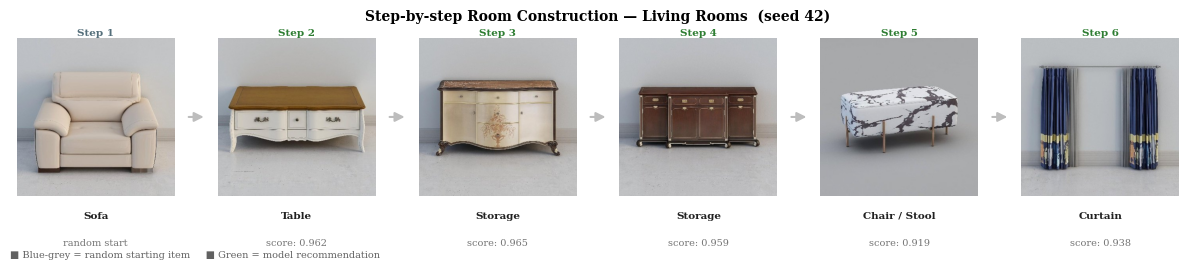

  Saved: fig4_chain__living_rooms__seed42.png

✓ All chain figures saved to: d:\Programing\thesis_v2_v3\data\thesis_figures\comparison


In [3]:
# Generate chains for both rooms, two different seeds each
ROOMS = ["bedrooms", "living_rooms"]
SEEDS = [0, 42]

for room in ROOMS:
    for seed in SEEDS:
        print(f"\n{ROOM_LABELS[room]}, seed={seed}")
        fig  = make_chain_figure(room, seed=seed)
        path = OUT_DIR / f"fig4_chain__{room}__seed{seed}.png"
        fig.savefig(path)
        plt.show()
        plt.close(fig)
        print(f"  Saved: {path.name}")

print(f"\n\u2713 All chain figures saved to: {OUT_DIR}")